In [1]:
import numpy as np
%matplotlib inline

from devito import configuration

configuration['log-level'] = 'WARNING'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from scipy import signal
from scipy.ndimage import gaussian_filter
from scipy.signal import correlate, convolve
from copy import deepcopy
from Function.util_additional import analisis_spektrum_source, dominant_frequency, plot_shot_gather, plot_all_shots, plot_wavefield_overlay, create_video_from_images
import os

In [3]:
# Contoh membaca file .mat
vp = np.loadtxt('Model/Marmousi-12_5.txt')
vp = vp

vp0 = deepcopy(vp)
vp0 = gaussian_filter(vp0, [10, 10]) #velocity model intial



waterheight = 41

vp0[:, :waterheight] = 1.5

In [4]:
#NBVAL_IGNORE_OUTPUT
from examples.seismic import Model, plot_velocity, Receiver

# Define a physical size
shape = (vp0.shape)  # Number of grid point (nx, nz)
spacing = (12.5, 12.5)  # Grid spacing in m. The domain size is now 1km by 1km
origin = (0.,0.)  # What is the location of the top left corner. This is necessary to define
nboundary = 160


model0 = Model(vp=vp0, origin=origin, shape=shape, spacing=spacing,
              space_order=2, nbl=nboundary, bcs="damp")


model1 = Model(vp=vp, origin=origin, shape=shape, spacing=spacing,
              space_order=2, nbl=nboundary, bcs="damp", grid = model0.grid)

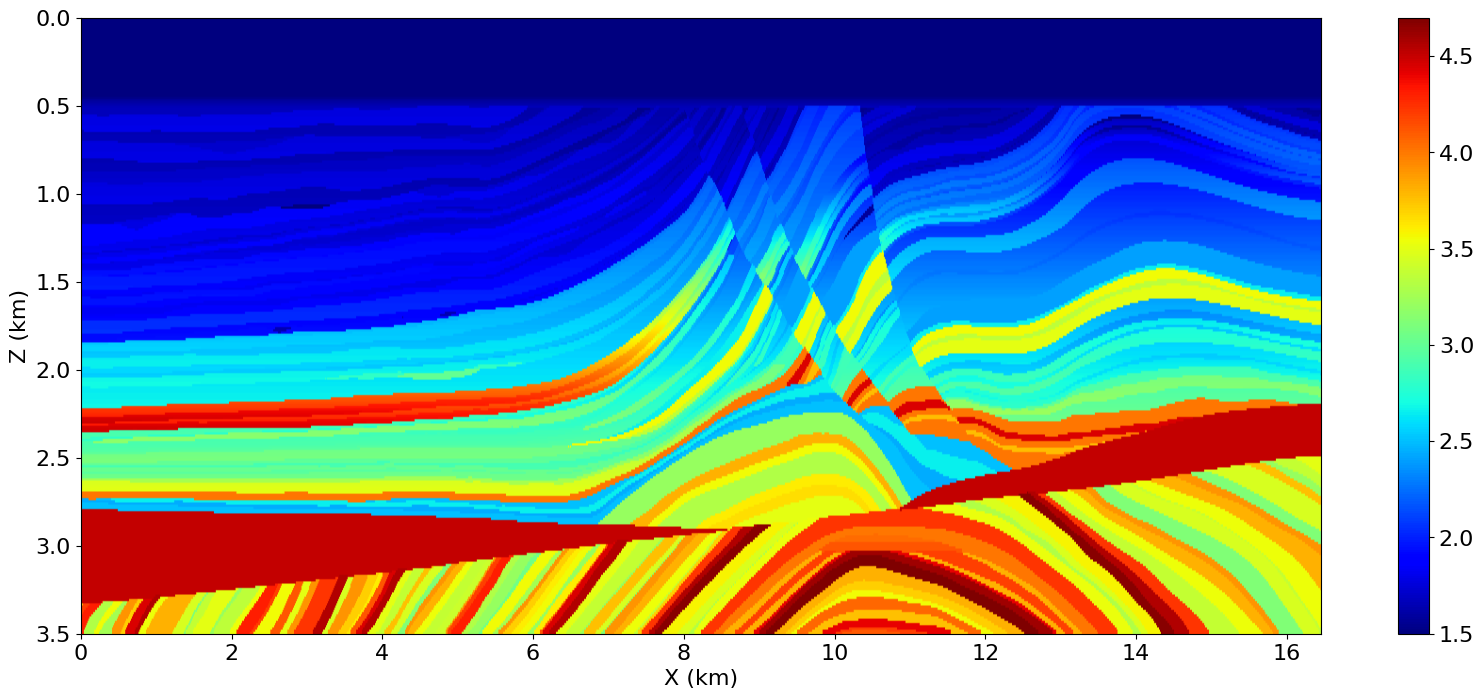

In [5]:
xmin = origin[0]
zmin = origin[1]
xmax = ((origin[0]*1000) + (shape[0]-1)*spacing[0])/1000
zmax = ((origin[1]*1000) + (shape[1]-1)*spacing[1])/1000
plt.figure(figsize=[20,8])
plt.imshow(model1.vp.data[nboundary:nboundary+shape[0], nboundary:nboundary+shape[1]].T, extent=[xmin, xmax, zmax, zmin], cmap='jet', vmin=1.5, vmax=4.7, aspect='auto')
plt.colorbar()
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.show()

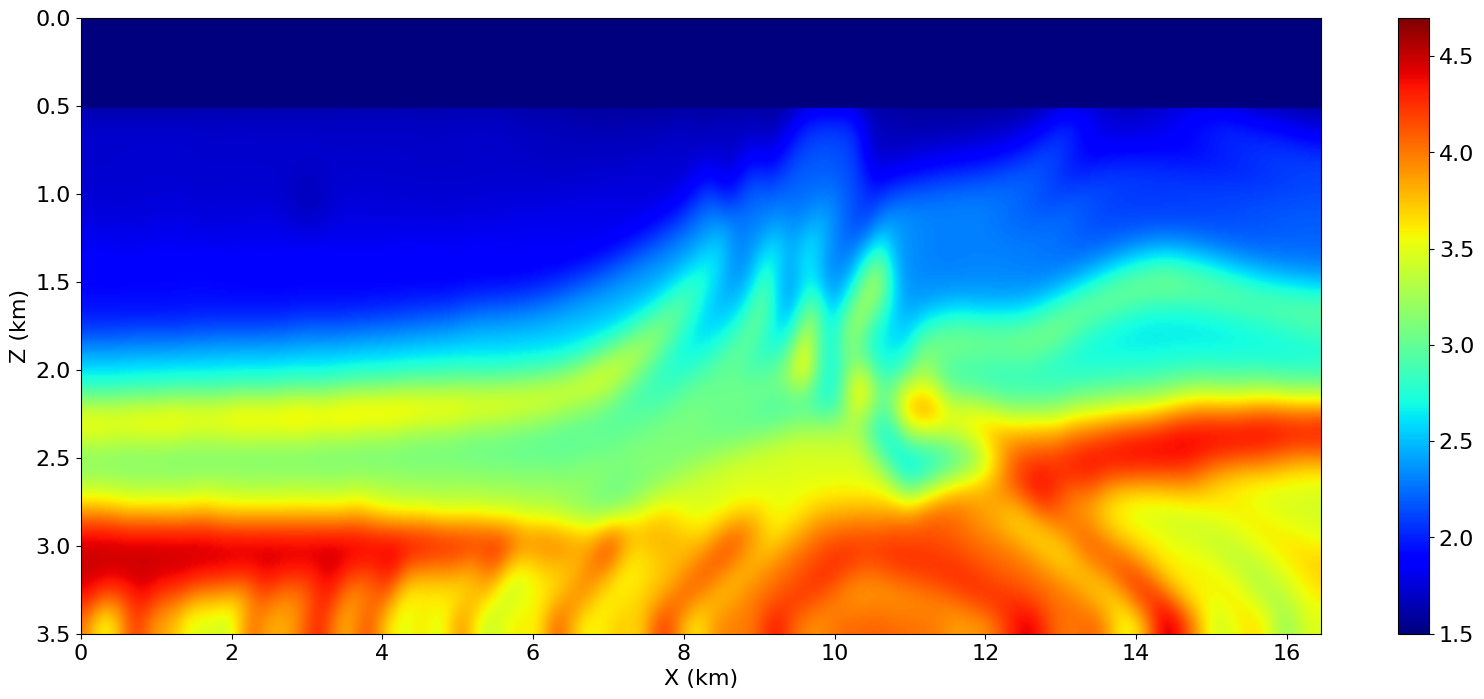

In [6]:
xmin = origin[0]
zmin = origin[1]
xmax = ((origin[0]*1000) + (shape[0]-1)*spacing[0])/1000
zmax = ((origin[1]*1000) + (shape[1]-1)*spacing[1])/1000
plt.figure(figsize=[20,8])
plt.imshow(model0.vp.data[nboundary:nboundary+shape[0], nboundary:nboundary+shape[1]].T, extent=[xmin, xmax, zmax, zmin], cmap='jet', vmin=1.5, vmax=4.7, aspect='auto')
plt.colorbar()
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.show()

In [7]:
#NBVAL_IGNORE_OUTPUT
# Define acquisition geometry: source
from examples.seismic import TimeAxis

#geometry define
#source geometry
nshots = 125  # Number of shots to create gradient from
shot_first_coordinate = 4050
shot_last_coordinate = 16450
shot_depth = 0

#receriver geometry
nreceivers = 160  # Number of receiver locations per shot 
first_channel_firstlreceriverline_coordinate = 75
last_channel_firstreceiverline_coordinate = 4050
receiverline_interval = 100
receiver_depth = 0



#recording define
dt = model1.critical_dt
t0 = 0.
tn = 4504.
timeAx = TimeAxis(start=t0, stop=tn, step=dt)


#source define
f0 = 0.008
shift_phase = 0


In [8]:
from examples.seismic import AcquisitionGeometry, RickerSource

def geometry_and_source(nshots, shot_first_coordinate, shot_last_coordinate, shot_depth, nreceivers, first_channel_firstlreceriverline_coordinate, last_channel_firstreceiverline_coordinate, receiver_depth, receiverline_interval, t0, tn, dt, f0, shift_phase):
    src_coordinates = np.empty((nshots, 2))
    src_coordinates[:, 0] = np.linspace(shot_first_coordinate, shot_last_coordinate, nshots)
    src_coordinates[:, 1] = shot_depth  # Depth is 20m

    geometrys = []

    for i in range(nshots):
        # Define acquisition geometry: receivers

        # Initialize receivers for synthetic and imaging data
        rec_coordinates = np.empty((nreceivers, 2))
        rec_coordinates[:, 0] = np.linspace(first_channel_firstlreceriverline_coordinate+(i*receiverline_interval), last_channel_firstreceiverline_coordinate+(i*receiverline_interval), nreceivers)
        rec_coordinates[:, 1] = receiver_depth  # Depth is 20m

        # Geometry
        geometry = AcquisitionGeometry(model1, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker', dt=dt)
        geometrys.append(geometry)


    t = np.arange(t0, 4504+dt, (dt))
    t = t/1000
    f0z = f0*1000
    t0 =   (1/f0z)
    st = (1 - (2*(np.pi**2)*(f0z**2)*(t-t0)**2))*(np.exp(-1*(np.pi**2)*(f0z**2)*(t-t0)**2))

    wavelet = st

    angle = shift_phase
    shifted = np.real(np.exp(1j*np.radians(angle)) * signal.hilbert(wavelet))
    shifted = np.array([shifted])
    shiftedT = shifted.T

    srcs = []

    for i in range(nshots):
        src = RickerSource(name='src', grid=model0.grid, f0=f0, time_range=timeAx)
        # First, position source centrally in all dimensions, then set depth
        src.coordinates.data[0, :] = src_coordinates[i, 0]
        src.coordinates.data[0, -1] = shot_depth  # Depth is 20m
        src.data[:] = shiftedT
        srcs.append(src)

    return geometrys, srcs

In [9]:
geometrys, srcs = geometry_and_source(nshots, shot_first_coordinate, shot_last_coordinate, shot_depth, nreceivers, first_channel_firstlreceriverline_coordinate, last_channel_firstreceiverline_coordinate, receiver_depth, receiverline_interval, t0, tn, dt, f0, shift_phase)

In [10]:
recs_coordinate = []

for i in range(nshots):
    recs_coordinate.append(geometrys[i].rec_positions)

recs_coordinate = np.array(recs_coordinate)


print(recs_coordinate.shape)
print(recs_coordinate[0])

(125, 160, 2)
[[  75.    0.]
 [ 100.    0.]
 [ 125.    0.]
 [ 150.    0.]
 [ 175.    0.]
 [ 200.    0.]
 [ 225.    0.]
 [ 250.    0.]
 [ 275.    0.]
 [ 300.    0.]
 [ 325.    0.]
 [ 350.    0.]
 [ 375.    0.]
 [ 400.    0.]
 [ 425.    0.]
 [ 450.    0.]
 [ 475.    0.]
 [ 500.    0.]
 [ 525.    0.]
 [ 550.    0.]
 [ 575.    0.]
 [ 600.    0.]
 [ 625.    0.]
 [ 650.    0.]
 [ 675.    0.]
 [ 700.    0.]
 [ 725.    0.]
 [ 750.    0.]
 [ 775.    0.]
 [ 800.    0.]
 [ 825.    0.]
 [ 850.    0.]
 [ 875.    0.]
 [ 900.    0.]
 [ 925.    0.]
 [ 950.    0.]
 [ 975.    0.]
 [1000.    0.]
 [1025.    0.]
 [1050.    0.]
 [1075.    0.]
 [1100.    0.]
 [1125.    0.]
 [1150.    0.]
 [1175.    0.]
 [1200.    0.]
 [1225.    0.]
 [1250.    0.]
 [1275.    0.]
 [1300.    0.]
 [1325.    0.]
 [1350.    0.]
 [1375.    0.]
 [1400.    0.]
 [1425.    0.]
 [1450.    0.]
 [1475.    0.]
 [1500.    0.]
 [1525.    0.]
 [1550.    0.]
 [1575.    0.]
 [1600.    0.]
 [1625.    0.]
 [1650.    0.]
 [1675.    0.]
 [1700.    

In [11]:
srcs_coordinate = np.array(geometrys[0].src_positions)


print(srcs_coordinate.shape)
print(srcs_coordinate)


(125, 2)
[[ 4050.     0.]
 [ 4150.     0.]
 [ 4250.     0.]
 [ 4350.     0.]
 [ 4450.     0.]
 [ 4550.     0.]
 [ 4650.     0.]
 [ 4750.     0.]
 [ 4850.     0.]
 [ 4950.     0.]
 [ 5050.     0.]
 [ 5150.     0.]
 [ 5250.     0.]
 [ 5350.     0.]
 [ 5450.     0.]
 [ 5550.     0.]
 [ 5650.     0.]
 [ 5750.     0.]
 [ 5850.     0.]
 [ 5950.     0.]
 [ 6050.     0.]
 [ 6150.     0.]
 [ 6250.     0.]
 [ 6350.     0.]
 [ 6450.     0.]
 [ 6550.     0.]
 [ 6650.     0.]
 [ 6750.     0.]
 [ 6850.     0.]
 [ 6950.     0.]
 [ 7050.     0.]
 [ 7150.     0.]
 [ 7250.     0.]
 [ 7350.     0.]
 [ 7450.     0.]
 [ 7550.     0.]
 [ 7650.     0.]
 [ 7750.     0.]
 [ 7850.     0.]
 [ 7950.     0.]
 [ 8050.     0.]
 [ 8150.     0.]
 [ 8250.     0.]
 [ 8350.     0.]
 [ 8450.     0.]
 [ 8550.     0.]
 [ 8650.     0.]
 [ 8750.     0.]
 [ 8850.     0.]
 [ 8950.     0.]
 [ 9050.     0.]
 [ 9150.     0.]
 [ 9250.     0.]
 [ 9350.     0.]
 [ 9450.     0.]
 [ 9550.     0.]
 [ 9650.     0.]
 [ 9750.     0.]
 [ 98

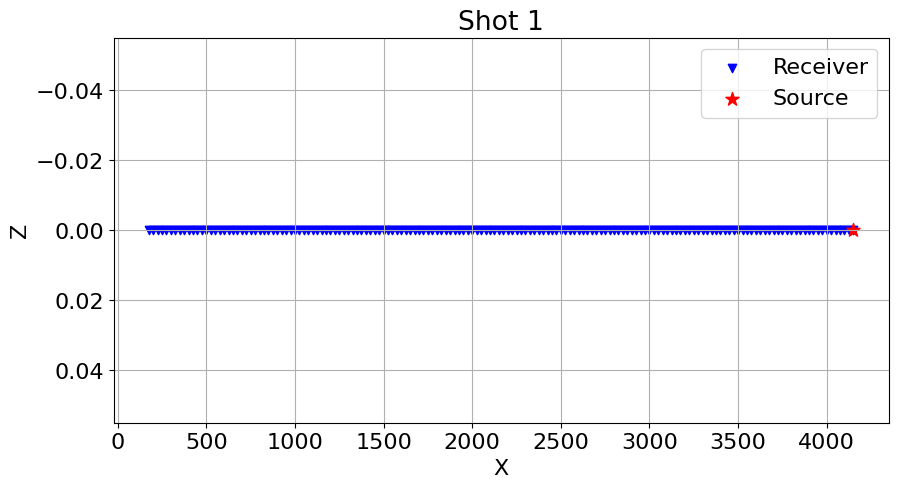

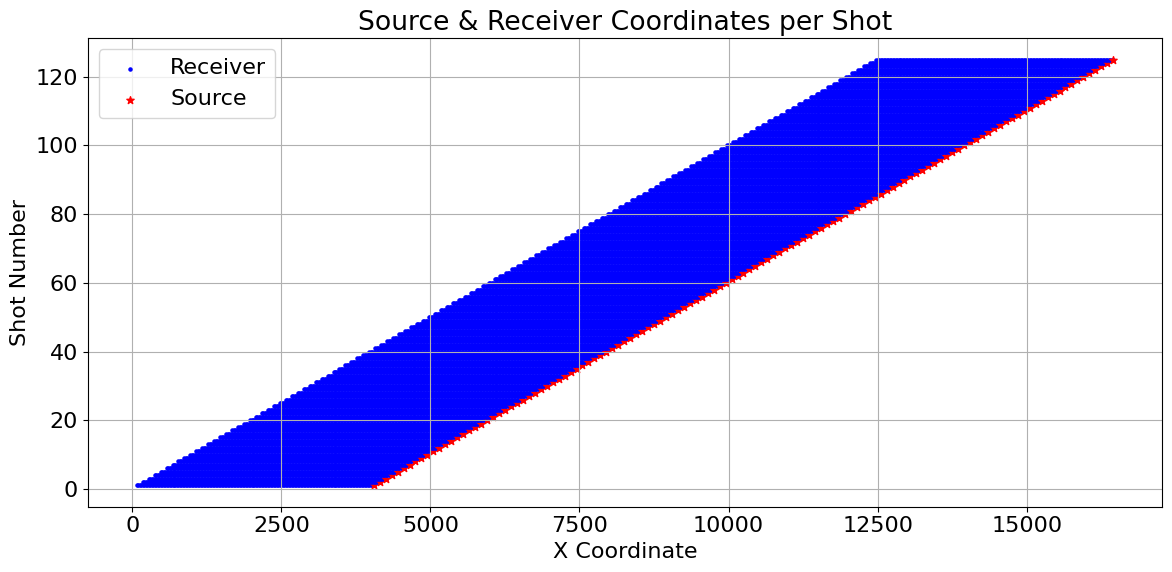

In [12]:
plot_shot_gather(recs_coordinate, srcs_coordinate, 1)
plot_all_shots(recs_coordinate, srcs_coordinate)

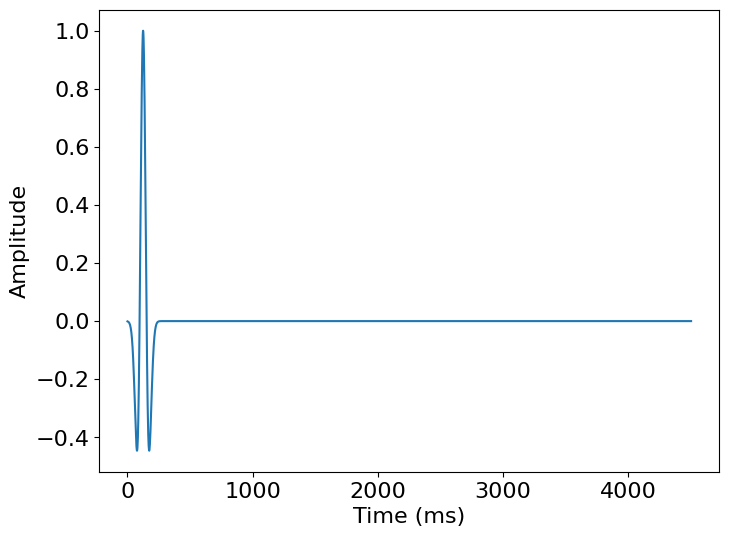

(2766, 1)
TimeAxis: start=0, stop=4504.19, step=1.629, num=2766


In [13]:
srcs[0].show()
print(srcs[0].data.shape)

print(geometrys[0])
print(geometrys[0].time_axis)

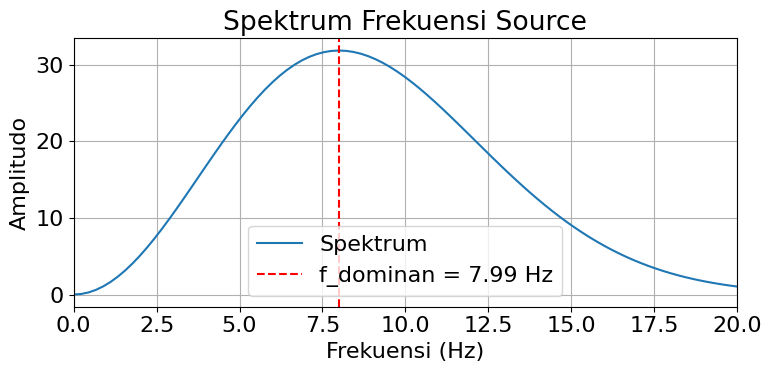

Frekuensi dominan: 7.99 Hz


In [14]:
f_dom = analisis_spektrum_source(srcs[0].data, dt=(dt/1000), zoom_x=[0,20])
print(f"Frekuensi dominan: {f_dom:.2f} Hz")

In [15]:
# Mencari indeks geophone terdekat untuk setiap shot
geometry = geometrys[0]
nearest_indices = []
i=0

for shot in geometry.src_positions:
    distances = np.linalg.norm(geometrys[i].rec_positions - shot, axis=1)  # Hitung jarak Euclidean
    nearest_index = np.argmin(distances)  # Cari indeks dengan jarak minimum
    nearest_indices.append(nearest_index)
    i+=1

nearest_indices = np.array(nearest_indices)

#nearest_indices -= 2

print(nearest_indices)

[159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159
 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159
 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159
 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159
 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159
 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159
 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159 159]


In [16]:
import segyio
import numpy as np
from collections import defaultdict

filename = 'SEGY Creation/Seismic Data/SEGY Marmousi 12-5.sgy'

# Dictionary untuk menyimpan shot gathers
shot_data = defaultdict(list)

with segyio.open(filename, "r", ignore_geometry=True) as segyfile:
    segyfile.mmap()
    n_traces = segyfile.tracecount
    n_samples = segyfile.samples.size
    
    # Ambil ID field record (shot number) per trace
    shot_ids = segyfile.attributes(segyio.TraceField.FieldRecord)[:]
    
    # Kelompokkan trace per shot
    for i in range(n_traces):
        shot_id = shot_ids[i]
        trace = segyfile.trace[i]
        shot_data[shot_id].append(trace)

# Ubah list trace per shot menjadi array (samples x trace)
shot_gathers = []
for shot_id, traces in shot_data.items():
    gather = np.stack(traces).T  # shape: (samples, traces)
    shot_gathers.append(gather)

# Contoh: akses shot ke-0
first_shot = shot_gathers[0]

data_obs = np.array(shot_gathers)
print("Shape of first shot:", first_shot.shape)


Shape of first shot: (2766, 160)


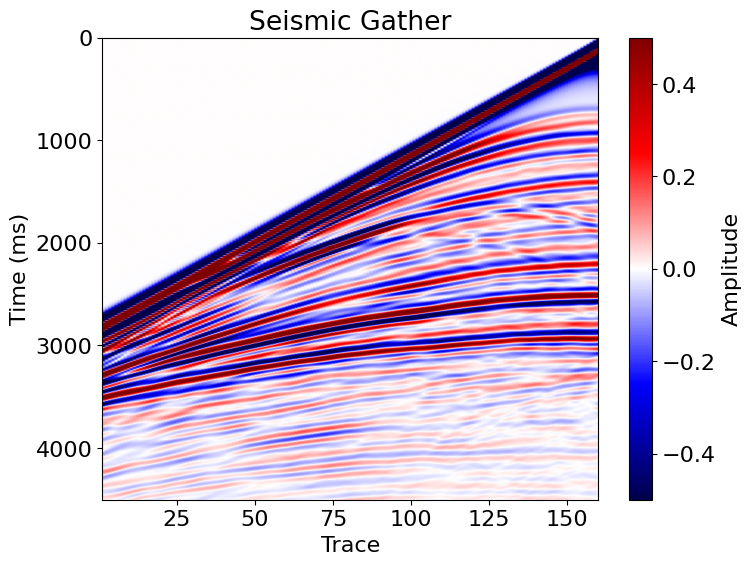

In [17]:
plt.imshow(data_obs[0], aspect='auto', cmap='seismic', extent=[1, 160, 4504, 0], vmax=0.5, vmin=-0.5)
plt.xlabel('Trace')
plt.ylabel('Time (ms)')
plt.title('Seismic Gather')
plt.colorbar(label='Amplitude')
plt.show()

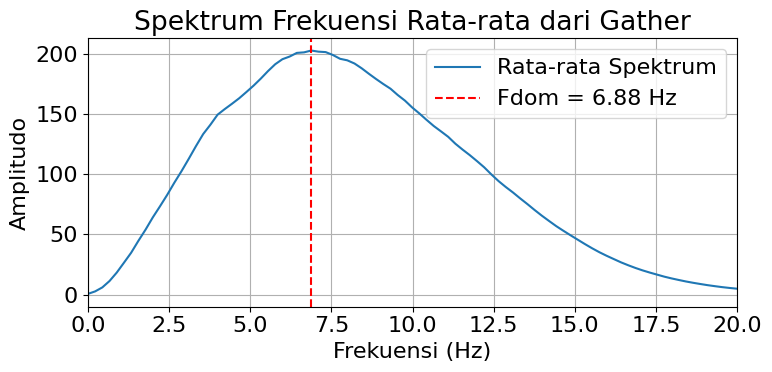

Frekuensi dominan: 6.88 Hz


In [18]:
# Misal kamu punya gather dengan shape (2000, 160), dt = 0.001 (1 ms)
f_dominan, frekuensi, spektrum = dominant_frequency(data_obs[0], dt=(dt/1000), zoom_x=[0, 20])
print(f"Frekuensi dominan: {f_dominan:.2f} Hz")

In [19]:
from devito import Eq, Operator

# Computes the residual between observed and synthetic data into the residual
def compute_residual(residual, dobs, dsyn, kg):
    if residual.grid.distributor.is_parallel:
        # If we run with MPI, we have to compute the residual via an operator
        # First make sure we can take the difference and that receivers are at the 
        # same position
        assert np.allclose(dobs.coordinates.data[:], dsyn.coordinates.data)
        assert np.allclose(residual.coordinates.data[:], dsyn.coordinates.data)
        # Create a difference operator
        diff_eq = Eq(residual, dsyn.subs({dsyn.dimensions[-1]: residual.dimensions[-1]}) -
                               dobs.subs({dobs.dimensions[-1]: residual.dimensions[-1]}))
        Operator(diff_eq)()
    else:
        # Data ukuran (1920 x 120)
        data_1 = dsyn.data[:]
        data_2 = dobs.data[:]

        # Data ukuran (1920 x 120)
        

        # Pastikan data_2 menjadi array 1D untuk keperluan konvolusi
        filter_data1 = dobs.data[:,kg]
        filter_data2 = dsyn.data[:,kg]


        for i in range(residual.data.shape[1]):
            # Panjang data asli
            len_data1 = len(data_1)

            # Panjang hasil korelasi
            len_full = len(convolve(filter_data1, data_1[:, i], mode='full'))

            # Indeks untuk mengambil nilai tengah
            start = (len_full - len_data1) // 2
            end = start + len_data1
            
            residual.data[:, i] = convolve(data_1[:, i], filter_data1, mode='full')[:len_data1] - convolve(data_2[:, i], filter_data2, mode='full')[:len_data1]
        
        misfit_SI = deepcopy(residual)
         # Data berukuran (1920 x 1)
        
        data_1 = dobs.data[:,kg]

        # Data berukuran (1920 x 120)
        data_2 = residual.data[:]    
        # Menyimpan hasil cross-correlation
        cross_correlations = []
        len_data = len(data_1)
        # Lakukan cross-correlation untuk setiap kolom di data_2
        for i in range(data_2.shape[1]):
            result = correlate(data_2[:, i], data_1, mode='full')[len_data-1:]
            cross_correlations.append(result)
        residual.data[:] = np.array(cross_correlations).T

        #residual.data[:,159] *=0
        #residual.data[:,158] *=0
        
        #residual.data[:] = ((residual.data[:] - residual.data[:].min())/(residual.data[:].max()-residual.data[:].min()))*((dobs.data[:].max()-dobs.data.min())+dobs.data.min())
    return misfit_SI

In [20]:
def misfit(vp_in):
    objective = 0.
    for i in range(nshots):
        # Compute synthetic data with forward operator 
        from examples.seismic.acoustic import AcousticWaveSolver

        solver = AcousticWaveSolver(model1, geometrys[i], space_order=2)
        
        # Create placeholders for the data residual and data
        residual = Receiver(name='residual', grid=model0.grid,
                            time_range=geometrys[i].time_axis, 
                            coordinates=geometrys[i].rec_positions)
        d_obs = Receiver(name='d_obs', grid=model0.grid,
                         time_range=geometrys[i].time_axis, 
                         coordinates=geometrys[i].rec_positions)
        d_syn = Receiver(name='d_syn', grid=model0.grid,
                        time_range=geometrys[i].time_axis, 
                        coordinates=geometrys[i].rec_positions)
        # Update source location
        #geometry.src_positions[0, :] = src_coordinates[i, :]

        # Generate synthetic data from true model
        #_, _, _ = solver.forward(vp=model.vp, src=srcs[i], rec=d_obs)
        d_obs.data[:] = data_resampled[i]

        # Compute smooth data and full forward wavefield u0
        _, _, _ = solver.forward(vp=vp_in.vp, src=srcs[i], rec=d_syn)

        # Compute gradient from data residual and update objective function 
        misfit_SI = compute_residual(residual, d_obs, d_syn, nearest_indices[i])
        objective += 0.5*norm(misfit_SI)**2
        #residual.data[:] = d_obs.data[:] - d_syn.data[:]
        #objective += 0.5*norm(residual)**2
    return objective
    

In [21]:
def cubic_interpolation(alpha0, alpha1, f0, f1, df0, df1):
    """
    alpha0 = 0 (biasanya)
    alpha1 = nilai alpha awal (misal 1)
    f0, f1 = nilai fungsi misfit di alpha0 dan alpha1
    df0, df1 = arah turun di alpha0 dan alpha1 (dot product grad * direction)
    """

    d1 = df0 + df1 - 3 * ((f0 - f1) / (alpha0 - alpha1))
    d2 = np.sign(alpha1 - alpha0) * np.sqrt(d1**2 - df0 * df1)

    alpha_new = alpha1 - (alpha1 - alpha0) * (df1 + d2 - d1) / (df1 - df0 + 2*d2)
    alpha_new = max(0.1 * alpha1, min(alpha_new, 0.9 * alpha1))
    return alpha_new


def linesearch(vp_in, ff, g, p, a=0.0001, b=0.1, l=1, max_iter=5, max_l=5., min_l= 0.1, scale_l = 2):
    from copy import deepcopy
    from devito import mmax
    import numpy as np
    import time as tm

    ni = 0
    g_inner = g.data[nboundary:-nboundary, nboundary:-nboundary]
    p_inner = p.data[nboundary:-nboundary, nboundary:-nboundary]
    gtp = np.sum(g_inner * p_inner) # gradien awal dot arah
    best_l = 0
    best_ff2 = ff
    gtp_best = np.copy(gtp)
    g2_best = deepcopy(g)

    l_option = 0.
    ff_option = 0.
    g_option = deepcopy(g)
    g_option = deepcopy(g)


    while ni < max_iter:
        vp2 = deepcopy(vp_in)
        vp2.vp.data[:] = vp_in.vp.data[:] + (l) * (p.data[:])
        vp2.vp.data[:] = np.clip(vp2.vp.data[:], 1.5, 4.7)

        start_time = tm.time()

        time_start = datetime.now()
        print("Program dimulai pada:", time_start.strftime("%H:%M:%S"))
        
        ff2, g2 = fwi_gradient(vp2.vp)
        end_time = tm.time()

        print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
        
        g2.data[:] *= -1
        g2_inner = g2.data[nboundary:-nboundary, nboundary:-nboundary]
        g2tp = np.sum(g2_inner[:] * p_inner)

        if l == 0:
            l = min_l


        if ff2 < ff :
           l_option = deepcopy(l)
           ff_option = deepcopy(ff2)
           g_option = deepcopy(g2)

        # Cek sufficient decrease (Armijo)
        print(f"ff2 = {ff2}, ff + a * l * gtp = {ff + a * l * gtp}, a*l*gtp = {a*l*gtp}")
        print(f"abs(g2tp) = {abs(g2tp)}, abs(b*gtp) = {abs(b*gtp)}")
        print(f"g2tp = {(g2tp)}, (b*gtp) = {(b*gtp)}")
        print(" ")
        if ff2 <= ff + a * l * gtp:
            # Simpan sebagai kandidat terbaik jika Armijo terpenuhi
            if best_l == 0 or ff2 < best_ff2:
                best_l = l
                best_ff2 = ff2
                gtp_best = deepcopy(g2tp)
                g2_best.data[:] = g2.data[:]

            # Cek curvature condition
            if (g2tp) >= (b * gtp):
                print(f"Strong Wolfe satisfied, l best : {l}")
                best_l = l
                best_ff2 = ff2
                gtp_best = deepcopy(g2tp)
                g2_best.data[:] = g2.data[:]

                return best_l, best_ff2, g2_best  # Strong Wolfe satisfied
            else:
                if l >= max_l:
                    if abs(l-best_l) <= 0.01:
                        print(f"Armijo satisfied but curvature not satisfied and best_l = {max_l}, l use : {l}")
                        return best_l, best_ff2, g2_best
                    else :
                        l = cubic_interpolation(best_l, l, best_ff2, ff2, gtp_best, g2tp)
                        print(f"Armijo satisfied but curvature not satisfied and l>{max_l}, l update : {l}")
                else:
                    l *= scale_l
                    print(f"Armijo satisfied but curvature not satisfied, l update : {l}")
            

        else:
          if ff2 < ff :
            if (g2tp) >= (b * gtp):
               l*=scale_l
               print(f"Armijo not satisfied, ff2 < ff, but curvature satisfied l update : {l}")
            else :
               l = cubic_interpolation(best_l, l, best_ff2, ff2, gtp_best, g2tp)
               print(f"Armijo not satisfied, ff2<ff, curvature not satisfied l update : {l}")
          else:
                l = cubic_interpolation(best_l, l, best_ff2, ff2, gtp_best, g2tp)
                print(f"nether wolve satisfied, l update : {l}")
        ni += 1
        nshots
    if best_l != 0 :
        print(f"Strong Wolfe not satisfied. Returning best Armijo-satisfying l : {best_l}")
        return best_l, best_ff2, g2_best
    else:
        if (l_option == 0):
            best_l = cubic_interpolation(best_l, l, best_ff2, ff2, gtp_best, g2tp)
            vp2 = deepcopy(vp_in)
            vp2.vp.data[:] = vp_in.vp.data[:] + (l) * (p.data[:])
            vp2.vp.data[:] = np.clip(vp2.vp.data[:], 1.5, 4.7)

            start_time = tm.time()
            time_start = datetime.now()
            
            print("Program dimulai pada:", time_start.strftime("%H:%M:%S"))

            ff2, g2 = fwi_gradient(vp2.vp)

            g2.data[:] *= -1
            
            end_time = tm.time()
            print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")


            best_ff2 = deepcopy(ff2)
            g2_best = deepcopy(g2)
            print(f"No condition satisfied. Returning l interpolated : {best_l}")
        else :
           best_l = deepcopy(l_option)
           best_ff2 = deepcopy(ff_option)
           g2_best = deepcopy(g_option)
        return best_l, best_ff2, g2_best

In [22]:

def cg_fr(g0, g1, p):
  g0_inner = g0.data[nboundary:-nboundary, nboundary:-nboundary]
  g1_inner = g1.data[nboundary:-nboundary, nboundary:-nboundary]
  B = np.sum(g0_inner*g1_inner)/np.sum(g0_inner*g0_inner)
  p.data[:] = -1*g1.data[:] + B*p.data[:]
  p.data[:] /= np.max(np.abs(p.data[:]))
  
  print(f"Nilai B : {B}")
  return p


def cg_pr(g0, g1, p):
    g0_inner = g0.data[nboundary:-nboundary, nboundary:-nboundary]
    g1_inner = g1.data[nboundary:-nboundary, nboundary:-nboundary]
    y = g1_inner - g0_inner
    B = np.sum(g1_inner * y) / np.sum(g0_inner * g0_inner)
    if B < 0:
        B = 0  # Reset jika tidak descent
    p.data[:] = -1 * g1.data[:] + B * p.data[:]
    p.data[:] /= np.max(np.abs(p.data[:]))

    print(f"Nilai B : {B}")
    return p

def cg_hs(g0, g1, p):
    g0_inner = g0.data[nboundary:-nboundary, nboundary:-nboundary]
    g1_inner = g1.data[nboundary:-nboundary, nboundary:-nboundary]
    p_inner = p.data[nboundary:-nboundary, nboundary:-nboundary]
    y = g1_inner - g0_inner
    denom = np.sum(p_inner * y)
    if denom == 0:
        B = 0  # Hindari pembagian nol
    else:
        B = np.sum(g1_inner * y) / denom
    if B < 0:
        B = 0  # Reset jika arah tidak descent
    p.data[:] = -1 * g1.data[:] + B * p.data[:]
    p.data[:] /= np.max(np.abs(p.data[:]))

    print(f"Nilai B : {B}")
    return p

In [23]:
# Create FWI gradient kernel 
from devito import Function, norm
from examples.seismic import Receiver

def fwi_gradient(vp_in):    
    # Create symbols to hold the gradient
    grad = Function(name="grad", grid=model0.grid)
    
    objective = 0.
    for i in range(nshots):
        # Compute synthetic data with forward operator 
        from Function.wavesolver import AcousticWaveSolver

        solver = AcousticWaveSolver(model1, geometrys[i], space_order=2)
        
        # Create placeholders for the data residual and data
        residual = Receiver(name='residual', grid=model0.grid,
                            time_range=geometrys[i].time_axis, 
                            coordinates=geometrys[i].rec_positions)
        d_obs = Receiver(name='d_obs', grid=model0.grid,
                         time_range=geometrys[i].time_axis, 
                         coordinates=geometrys[i].rec_positions)
        d_syn = Receiver(name='d_syn', grid=model0.grid,
                        time_range=geometrys[i].time_axis, 
                        coordinates=geometrys[i].rec_positions)

        
        # Update source location
        #geometry.src_positions[0, :] = src_coordinates[i, :]

        # Generate synthetic data from true model
        #_, _, _ = solver.forward(vp=model.vp, src=srcs[0i, rec=d_obs)
        d_obs.data[:] = data_obs[i]

        # Compute smooth data and full forward wavefield u0
        _, u0, _ = solver.forward(vp=vp_in, save=True, src=srcs[i], rec=d_syn)
        
        #plot_shotrecord(d_syn.data[:], mresidual.data[:,159] *=0odel0, t0,tn)
        # Compute gradient from data residual and update objective function 
        misfit_SI = compute_residual(residual, d_obs, d_syn, nearest_indices[i])
        objective += .5*norm(misfit_SI)**2
        
        #residual.data[:] = d_obs.data[:] - d_syn.data[:]
        #objective += .5*norm(residual)**2
        
        #plot_shotrecord(residual.data, model, t0, tn)
        solver.gradient(rec=residual, u=u0, vp=vp_in, grad=grad)
        
        
    gradNormalized = Function(name="gradNormalized", grid=model0.grid)
    #Normalisasi ke rentang [-1, 1]
    gradNormalized.data[:] = grad.data[:]
    gradNormalized.data[:] *= watermute.data[:]
    gradNormalized.data[:] = gaussian_filter(gradNormalized.data[:], sigma = [2,2])
    gradNormalized.data[:] = gradNormalized.data[:]/np.max(np.abs(gradNormalized.data[:]))
    
    return objective, gradNormalized

In [24]:
model0.m

vp(x, y)**(-2)

In [25]:
from devito import Function

watermute = Function(name="watermute", grid=model0.grid)
watermute.data[:,nboundary+waterheight:] += 1

In [ ]:
from Function.wavesolver import AcousticWaveSolver

n_shot = 62

vp_in = model0.vp


solver = AcousticWaveSolver(model1, geometrys[n_shot], space_order=2)
        

grad = Function(name="grad", grid=model0.grid)
        # Create placeholders for the data residual and data
residual = Receiver(name='residual', grid=model0.grid,
                            time_range=geometrys[n_shot].time_axis, 
                            coordinates=geometrys[n_shot].rec_positions)
d_obs = Receiver(name='d_obs', grid=model0.grid,
                         time_range=geometrys[n_shot].time_axis, 
                         coordinates=geometrys[n_shot].rec_positions)
d_syn = Receiver(name='d_syn', grid=model0.grid,
                        time_range=geometrys[n_shot].time_axis, 
                        coordinates=geometrys[n_shot].rec_positions)

        
        # Update source location
        #geometry.src_positions[0, :] = src_coordinates[i, :]

        # Generate synthetic data from true model
        #_, _, _ = solver.forward(vp=model.vp, src=srcs[0i, rec=d_obs)
d_obs.data[:] = data_obs[n_shot]

        # Compute smooth data and full forward wavefield u0
_, u0, _ = solver.forward(vp=vp_in, save=True, src=srcs[n_shot], rec=d_syn)
        
        #plot_shotrecord(d_syn.data[:], model0, t0,tn)
        # Compute gradient from data residual and update objective function 
compute_residual(residual, d_obs, d_syn, nearest_indices[n_shot])
#residual.data[:] = d_obs.data[:] - d_syn.data[:]
        
objective = .5*norm(residual)**2


        #plot_shotrecord(residual.data, model, t0, tn)
_, v0, _ = solver.adjoint(rec=residual, vp=vp_in, save=True)



solver.gradient(rec=residual, u=u0, vp=vp_in, grad=grad)

gradNormalized = Function(name="gradNormalized", grid=model0.grid)

#Normalisasi ke rentang [-1, 1]
gradNormalized.data[:] = grad.data[:]
gradNormalized.data[:] *= watermute.data[:]
gradNormalized.data[:] = gaussian_filter(gradNormalized.data[:], sigma = [2,2])
gradNormalized.data[:] = gradNormalized.data[:]/np.max(np.abs(gradNormalized.data[:]))

No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source


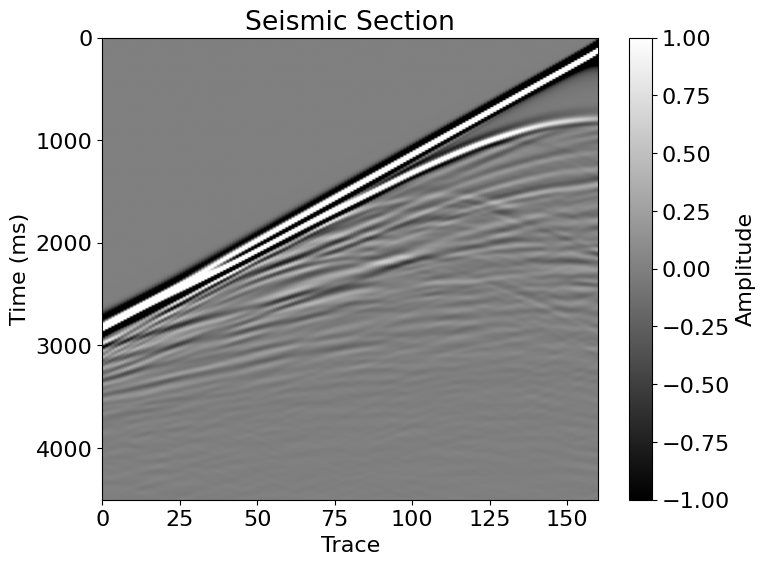

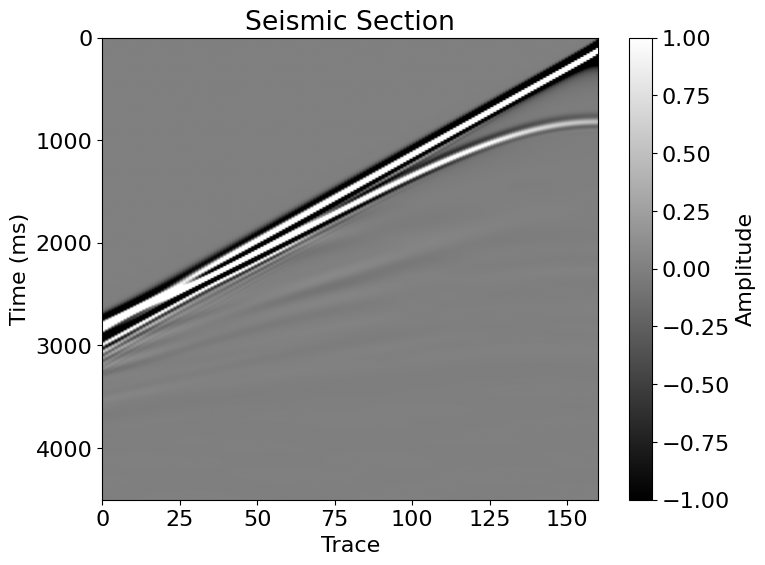

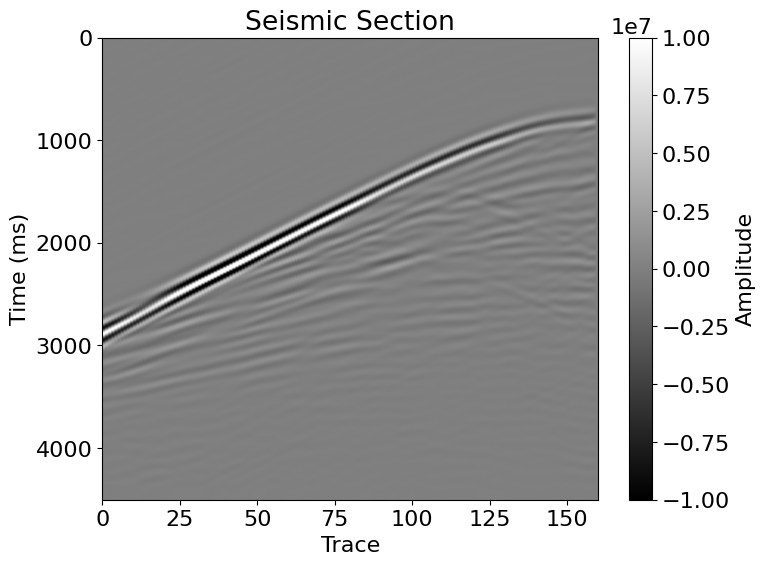

In [ ]:
plt.imshow(d_obs.data[:], aspect='auto', cmap='gray', extent=[0, 160, 4504, 0], vmin=-1, vmax=1)
plt.xlabel('Trace')
plt.ylabel('Time (ms)')
plt.title('Seismic Section')
plt.colorbar(label='Amplitude')
plt.show()
plt.imshow(d_syn.data[:], aspect='auto', cmap='gray', extent=[0, 160, 4504, 0], vmin=-1, vmax=1)
plt.xlabel('Trace')
plt.ylabel('Time (ms)')
plt.title('Seismic Section')
plt.colorbar(label='Amplitude')
plt.show()
plt.imshow(residual.data[:], aspect='auto', cmap='gray', extent=[0, 160, 4504, 0], vmin=-1e7, vmax=1e7)
plt.xlabel('Trace')
plt.ylabel('Time (ms)')
plt.title('Seismic Section')
plt.colorbar(label='Amplitude')
plt.show()

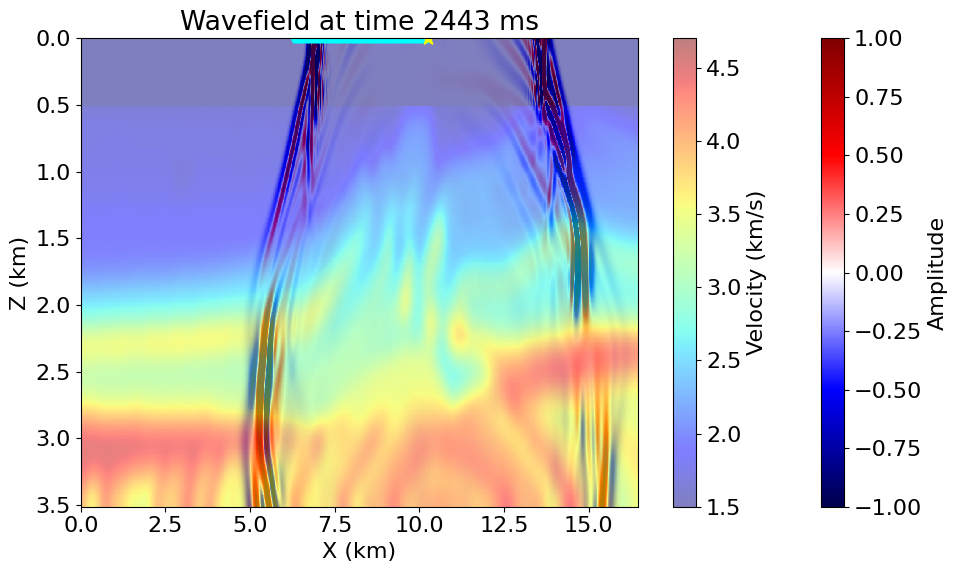

In [ ]:
plot_wavefield_overlay(velocity=model0, wavefield=u0, dt=dt, time_step=int(1500), origin=origin, spacing=spacing, shape=shape, nboundary=nboundary, shot_coordinate=srcs_coordinate[n_shot], receiver_coordinate=recs_coordinate[n_shot], show=True, cmap_wave='seismic', alpha=0.5, SeisAmpMin=-1, SeisAmpMax=1)

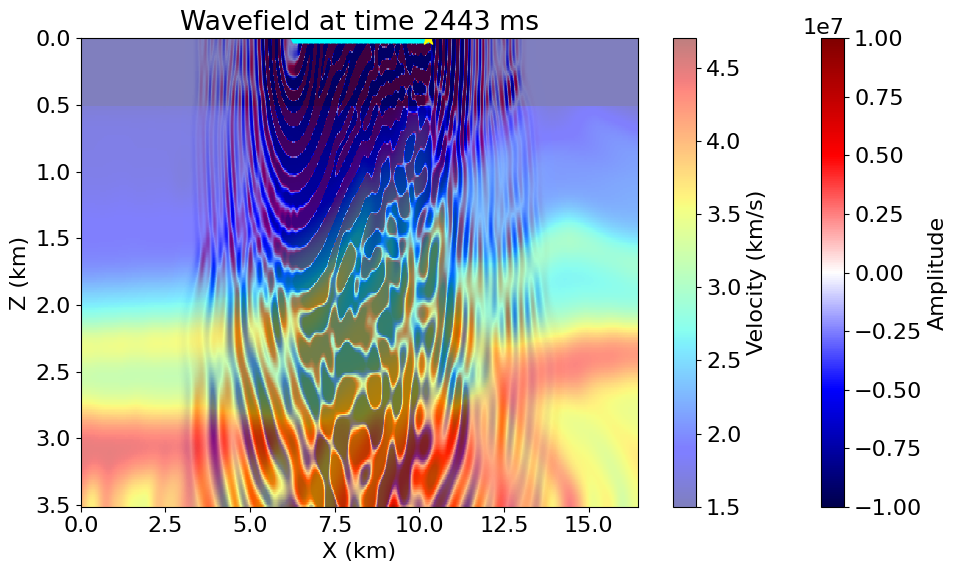

In [ ]:
plot_wavefield_overlay(velocity=model0, wavefield=v0, dt=dt, time_step=int(1500), origin=origin, spacing=spacing, shape=shape, nboundary=nboundary, shot_coordinate=srcs_coordinate[n_shot], receiver_coordinate=recs_coordinate[n_shot], show=True, cmap_wave='seismic', alpha=0.5, SeisAmpMin=-1e7, SeisAmpMax=1e7)

In [ ]:
tipe_wavefield = "Forward"
frekuensi_wavefield = "8"
clear = True

image_folder = f"Snapshot/{tipe_wavefield}/{frekuensi_wavefield}Hz"
output_video = f"Snapshot/{tipe_wavefield}/{frekuensi_wavefield}Hz/{tipe_wavefield}-{frekuensi_wavefield}Hz.mp4"


if (clear) :
    for filename in os.listdir(image_folder):
        file_path = os.path.join(image_folder, filename)

        if os.path.isfile(file_path):
            os.remove(file_path)

    print("All files deleted.")


shot = [0, 62, 124]
shot_loc = 62
nt_end = u0.shape[0]-1
n_frame = 100
int_frame = int(nt_end/n_frame)

for i in range(n_frame):
    plot_wavefield_overlay(velocity=model0, wavefield=u0, dt=dt, time_step=int(int_frame*i), origin=origin, spacing=spacing, shape=shape, nboundary=nboundary, shot_coordinate=srcs_coordinate[shot_loc], receiver_coordinate=recs_coordinate[shot_loc], show=False, cmap_wave='seismic', alpha=0.5, save=True, path=image_folder, SeisAmpMin=-1, SeisAmpMax=1)


create_video_from_images(image_folder, output_video, 5)

All files deleted.
Mulai membuat video dari 100 gambar...


ffmpeg version n4.3.1 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7 (Ubuntu 7.5.0-3ubuntu1~18.04)
  configuration: --prefix= --prefix=/usr --disable-debug --disable-doc --disable-static --enable-cuda --enable-cuda-sdk --enable-cuvid --enable-libdrm --enable-ffplay --enable-gnutls --enable-gpl --enable-libass --enable-libfdk-aac --enable-libfontconfig --enable-libfreetype --enable-libmp3lame --enable-libnpp --enable-libopencore_amrnb --enable-libopencore_amrwb --enable-libopus --enable-libpulse --enable-sdl2 --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libv4l2 --enable-libvorbis --enable-libvpx --enable-libx264 --enable-libx265 --enable-libxcb --enable-libxvid --enable-nonfree --enable-nvenc --enable-omx --enable-openal --enable-opencl --enable-runtime-cpudetect --enable-shared --enable-vaapi --enable-vdpau --enable-version3 --enable-xlib
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 

Video berhasil dibuat di: Snapshot/Forward/8Hz/Forward-8Hz.mp4


frame=  100 fps=0.0 q=-1.0 Lsize=     626kB time=00:00:19.40 bitrate= 264.2kbits/s speed=37.1x    
video:624kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.317262%
[libx264 @ 0x5f5cbe08bb00] frame I:1     Avg QP:11.80  size: 39278
[libx264 @ 0x5f5cbe08bb00] frame P:29    Avg QP:18.14  size: 10743
[libx264 @ 0x5f5cbe08bb00] frame B:70    Avg QP:21.06  size:  4101
[libx264 @ 0x5f5cbe08bb00] consecutive B-frames:  5.0%  2.0%  9.0% 84.0%
[libx264 @ 0x5f5cbe08bb00] mb I  I16..4: 51.3% 29.9% 18.8%
[libx264 @ 0x5f5cbe08bb00] mb P  I16..4:  1.6%  5.9%  1.2%  P16..4: 12.9%  5.5%  3.0%  0.0%  0.0%    skip:69.9%
[libx264 @ 0x5f5cbe08bb00] mb B  I16..4:  0.3%  2.1%  0.2%  B16..8: 14.9%  2.8%  0.8%  direct: 2.0%  skip:76.9%  L0:51.0% L1:31.5% BI:17.5%
[libx264 @ 0x5f5cbe08bb00] 8x8 transform intra:65.6% inter:73.9%
[libx264 @ 0x5f5cbe08bb00] coded y,uvDC,uvAC intra: 42.8% 61.3% 49.1% inter: 6.2% 12.4% 4.4%
[libx264 @ 0x5f5cbe08bb00] i16 v,h,dc,p: 42% 36% 10% 11%
[l

In [ ]:
tipe_wavefield = "Adjoint"
frekuensi_wavefield = "8"
clear = True

image_folder = f"Snapshot/{tipe_wavefield}/{frekuensi_wavefield}Hz"
output_video = f"Snapshot/{tipe_wavefield}/{frekuensi_wavefield}Hz/{tipe_wavefield}-{frekuensi_wavefield}Hz.mp4"


if (clear) :
    for filename in os.listdir(image_folder):
        file_path = os.path.join(image_folder, filename)

        if os.path.isfile(file_path):
            os.remove(file_path)

    print("All files deleted.")


shot = [0, 62, 124]
shot_loc = 62
nt_end = u0.shape[0]-1
n_frame = 100
int_frame = int(nt_end/n_frame)

for i in range(n_frame):
    plot_wavefield_overlay(velocity=model0, wavefield=v0, dt=dt, time_step=int(int_frame*i), origin=origin, spacing=spacing, shape=shape, nboundary=nboundary, shot_coordinate=srcs_coordinate[shot_loc], receiver_coordinate=recs_coordinate[shot_loc], show=False, cmap_wave='seismic', alpha=0.5, save=True, path=image_folder, SeisAmpMin=-1e7, SeisAmpMax=1e7)


create_video_from_images(image_folder, output_video, 5)

All files deleted.
Mulai membuat video dari 100 gambar...


ffmpeg version n4.3.1 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7 (Ubuntu 7.5.0-3ubuntu1~18.04)
  configuration: --prefix= --prefix=/usr --disable-debug --disable-doc --disable-static --enable-cuda --enable-cuda-sdk --enable-cuvid --enable-libdrm --enable-ffplay --enable-gnutls --enable-gpl --enable-libass --enable-libfdk-aac --enable-libfontconfig --enable-libfreetype --enable-libmp3lame --enable-libnpp --enable-libopencore_amrnb --enable-libopencore_amrwb --enable-libopus --enable-libpulse --enable-sdl2 --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libv4l2 --enable-libvorbis --enable-libvpx --enable-libx264 --enable-libx265 --enable-libxcb --enable-libxvid --enable-nonfree --enable-nvenc --enable-omx --enable-openal --enable-opencl --enable-runtime-cpudetect --enable-shared --enable-vaapi --enable-vdpau --enable-version3 --enable-xlib
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 

Video berhasil dibuat di: Snapshot/Adjoint/8Hz/Adjoint-8Hz.mp4


frame=  100 fps=0.0 q=-1.0 Lsize=    2579kB time=00:00:19.40 bitrate=1089.0kbits/s speed=29.7x    
video:2577kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.078899%
[libx264 @ 0x5fe3d9f7f7c0] frame I:1     Avg QP:17.39  size: 86076
[libx264 @ 0x5fe3d9f7f7c0] frame P:25    Avg QP:17.36  size: 36712
[libx264 @ 0x5fe3d9f7f7c0] frame B:74    Avg QP:21.35  size: 22084
[libx264 @ 0x5fe3d9f7f7c0] consecutive B-frames:  1.0%  0.0%  3.0% 96.0%
[libx264 @ 0x5fe3d9f7f7c0] mb I  I16..4: 26.5% 56.3% 17.1%
[libx264 @ 0x5fe3d9f7f7c0] mb P  I16..4:  0.9%  9.3%  5.9%  P16..4:  7.6%  8.0%  5.7%  0.0%  0.0%    skip:62.6%
[libx264 @ 0x5fe3d9f7f7c0] mb B  I16..4:  0.3%  1.8%  2.1%  B16..8: 13.7%  8.6%  5.1%  direct: 3.5%  skip:64.9%  L0:35.6% L1:24.5% BI:40.0%
[libx264 @ 0x5fe3d9f7f7c0] 8x8 transform intra:51.7% inter:58.8%
[libx264 @ 0x5fe3d9f7f7c0] coded y,uvDC,uvAC intra: 71.6% 76.8% 74.5% inter: 19.3% 23.9% 17.4%
[libx264 @ 0x5fe3d9f7f7c0] i16 v,h,dc,p: 55% 29%  9%  6%

In [ ]:
from IPython.display import Video
output_video_forward = "Snapshot/Forward/8Hz/Forward-8Hz.mp4"

Video(output_video_forward, embed=True)

In [ ]:
from IPython.display import Video
output_video_adjoint = "Snapshot/Adjoint/8Hz/Adjoint-8Hz.mp4"


Video(output_video_adjoint, embed=True)

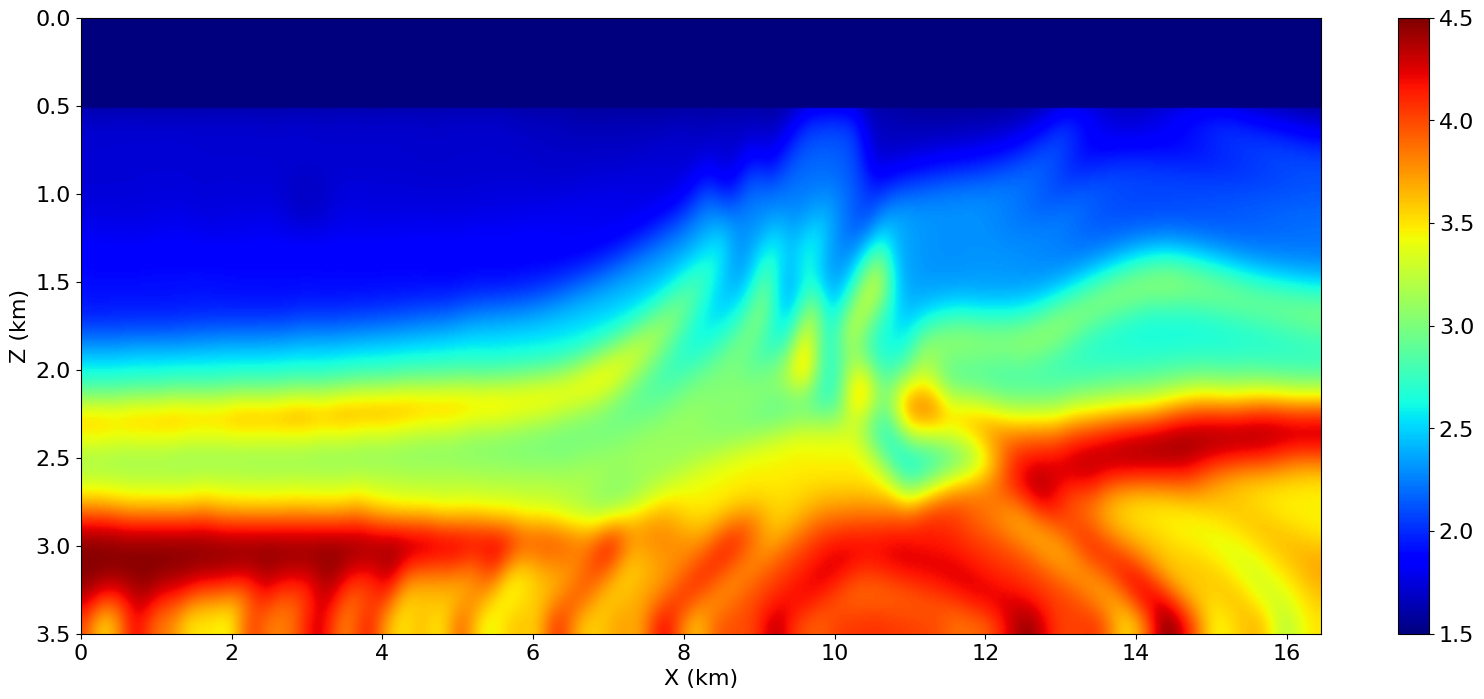

Proses FWI freq 0.008
Program dimulai pada: 15:58:46


In [ ]:
from copy import deepcopy
from devito import mmax, norm
import time as tm
from datetime import datetime

multiscale_freq = np.array([ 8.])
multiscale_freq /= 1000

modelbest_each_freq = []


update_model = Model(vp=vp0, origin=origin, shape=shape, spacing=spacing,
            space_order=2, nbl=nboundary, bcs="damp", grid = model0.grid)

#update_model.vp.data[:] = np.loadtxt("Model_Progres/Best Model 2.0 Hz Vp0 Rev1.txt")

xmin = origin[0]
zmin = origin[1]
xmax = ((origin[0]*1000) + (shape[0]-1)*spacing[0])/1000
zmax = ((origin[1]*1000) + (shape[1]-1)*spacing[1])/1000
plt.figure(figsize=(20, 8))
plt.imshow(update_model.vp.data[nboundary:nboundary+shape[0], nboundary:nboundary+shape[1]].T, extent=[xmin, xmax, zmax, zmin], cmap='jet', vmin=1.5, vmax=4.5, aspect='auto')
plt.colorbar()
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.show()


for k in multiscale_freq:
    print(f"Proses FWI freq {k}")

    geometrys, srcs = geometry_and_source(nshots, shot_first_coordinate, shot_last_coordinate, shot_depth, nreceivers, first_channel_firstlreceriverline_coordinate, last_channel_firstreceiverline_coordinate, receiver_depth, receiverline_interval, t0, tn, dt, k, shift_phase)
    
    misfiti = []
    modeli =[]
    gradi = []
    #plot_velocity(update_model)
    model_update = deepcopy(update_model.vp.data[:])
    modeli.append(model_update)

    fwi_iterations = 10  # Number of outer FWI iteration
    fwi_index = 0
    for i in range(fwi_iterations):
        if i==0 :
            start_time = tm.time()
            

            time_start = datetime.now()
            print("Program dimulai pada:", time_start.strftime("%H:%M:%S"))

            
            ff, update = fwi_gradient(update_model.vp)
            
            end_time = tm.time()

            print("")
            print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
            print("")
            

            gradient = deepcopy(update)
            gradient.data[:] *= -1

        else :
            ff, gradient1 = FF, G

            update1 = deepcopy(gradient1)
            update1.data[:] *= -1

            update = cg_hs(gradient, gradient1, update)

            '''if np.sum(gradient1.data[:]*update.data[:]) >= 0:
                update.data[:] = deepcopy(gradient1.data[:])
                update.data[:] *= -1'''
      
            gradient = deepcopy(gradient1)

        print(f"Maksimum p : {np.max(update.data)}")
        print(f"Minimum p : {np.min(update.data)}")
        print(f"Norm P : {norm(update)}")


        misfit_model = deepcopy(ff)
        misfiti.append(misfit_model)

        updatei = deepcopy(update.data[:])
        gradi.append(updatei)


        print(f" ")
        print(f"===========================================================")
        print(f"FWI freq {k} iterasi ke-{fwi_index}/{fwi_iterations} : {ff}")
    

        L, FF, G = linesearch(update_model, ff, gradient, update, a=0.0001, b=0.1, l=1, max_iter=5, max_l = 100, scale_l=2) 

    
        update_model.vp.data[:] += ((L))*update.data[:]
        update_model.vp.data[:] = np.clip(update_model.vp.data[:], 1.5, 4.7)

        model_update = deepcopy(update_model.vp.data[:])
        modeli.append(model_update)
    
        fwi_index+=1

        plt.figure(figsize=(20, 8))
        plt.imshow(update.data[nboundary:nboundary+shape[0], nboundary:nboundary+shape[1]].T, extent=[xmin, xmax, zmax, zmin], cmap='seismic', vmin=-1, vmax=1, aspect='auto')
        plt.colorbar()
        plt.xlabel("X (km)")
        plt.ylabel("Z (km)")
        plt.show()


        plt.figure(figsize=(20, 8))
        plt.imshow(update_model.vp.data[nboundary:nboundary+shape[0], nboundary:nboundary+shape[1]].T, extent=[xmin, xmax, zmax, zmin], cmap='jet', vmin=1.5, vmax=4.5, aspect='auto')
        plt.colorbar()
        plt.xlabel("X (km)")
        plt.ylabel("Z (km)")
        plt.show()
    
    ff = FF
    misfit_model = deepcopy(ff)
    misfiti.append(misfit_model)

    print(f" ")
    print(f"===========================================================")
    print(f"FWI freq {k} iterasi ke-{fwi_index}/{fwi_iterations} : {ff}")

    best_model = deepcopy(update_model.vp.data[:])

    modelbest_each_freq.append(best_model)

    np.savetxt(f'Model_Progres/Best Model {k*1000} Hz Smoothed.txt', best_model)
    np.savetxt(f'Model_Progres/Misfit {k*1000} Hz Smoothed.txt', misfiti)
    np.save(f'Model_Progres/Update Model {k*1000} Hz Smoothed.npy', modeli)
    np.save(f'Model_Progres/Gradient Model {k*1000} Hz Smoothed.npy', gradi)

    
    plt.figure(figsize=(20, 8))
    plt.imshow(update_model.vp.data[nboundary:nboundary+shape[0], nboundary:nboundary+shape[1]].T, extent=[xmin, xmax, zmax, zmin], cmap='jet', vmin=1.5, vmax=4.5, aspect='auto')
    plt.colorbar()
    plt.xlabel("X (km)")
    plt.ylabel("Z (km)")
    plt.show()

(1317, 281)


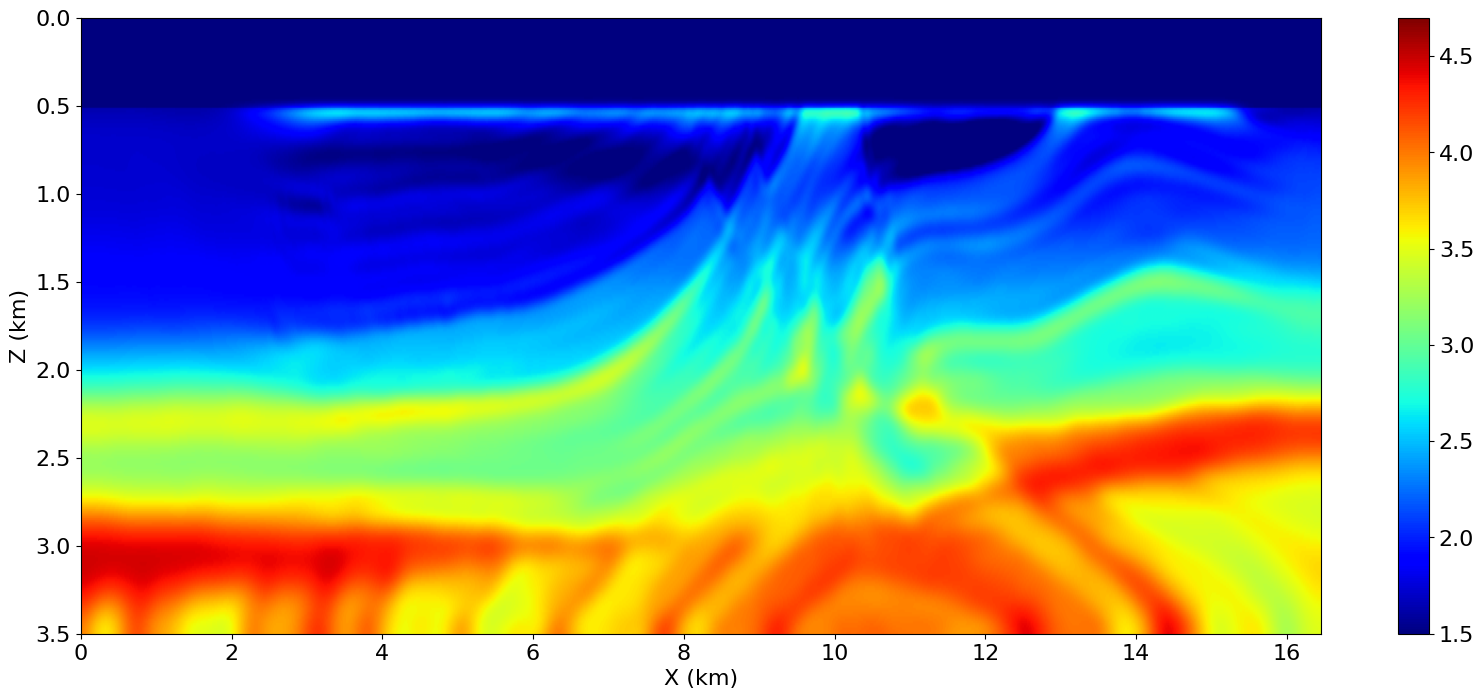

In [ ]:
from copy import deepcopy

model_cek = deepcopy(model0)

# Load file
model_cek.vp.data[:] = np.loadtxt('Model_Progres/Best Model 8.0 Hz Smoothed.txt')

best_model_smoothed = model_cek.vp.data[nboundary:-nboundary, nboundary:-nboundary]


# Cek hasilnya
print(best_model_smoothed.shape)



xmin = origin[0]
zmin = origin[1]
xmax = ((origin[0]*1000) + (shape[0]-1)*spacing[0])/1000
zmax = ((origin[1]*1000) + (shape[1]-1)*spacing[1])/1000
plt.figure(figsize=(20, 8))
plt.imshow(best_model_smoothed.T, extent=[xmin, xmax, zmax, zmin], cmap='jet', aspect='auto', vmin = 1.5, vmax=4.7)
plt.colorbar()
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.show()

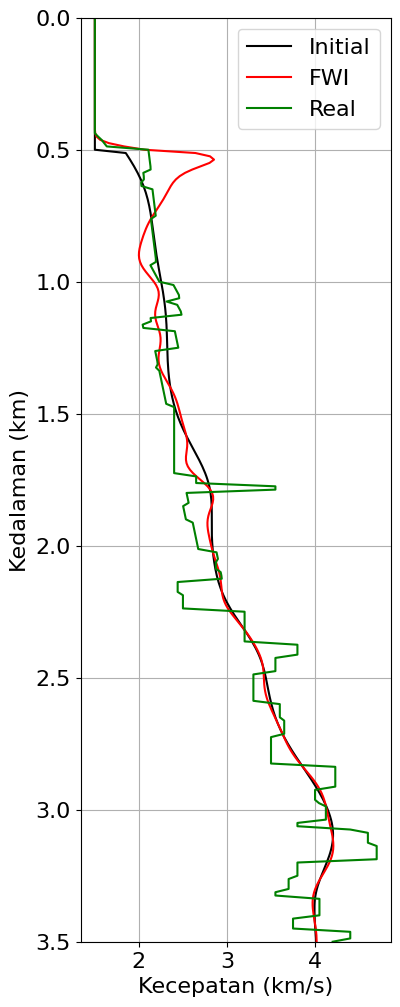

In [ ]:
velocity_initial = vp0[801,:]
velocity_fwi = best_model_smoothed[801,:]
velocity_real = vp[801,:]
DEPTH = np.arange(281)*0.0125


plt.figure(figsize=(4, 12))
plt.plot(velocity_initial, DEPTH, color='black', label="Initial")
plt.plot(velocity_fwi, DEPTH, color='red', label="FWI")
plt.plot(velocity_real, DEPTH, color='green', label="Real")
plt.gca().invert_yaxis()  # Membalik sumbu Y agar kedalaman meningkat ke bawah
plt.xlabel('Kecepatan (km/s)')
plt.ylabel('Kedalaman (km)')
plt.ylim(3.5,0)
#plt.title('Profil Kecepatan (X : 14 km)')
plt.grid(True)
#plt.tight_layout()
plt.legend()
plt.show()